In [1]:
import pandas as pd
df = pd.read_csv("Telco_Customer_Churn.csv")
print(df.shape)
print(df["Churn"].value_counts())
df.head()

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
dfcopy = df.copy()
dfcopy["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("so dong thieu:", dfcopy["TotalCharges"].isna().sum())
dfcopy[dfcopy["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

so dong thieu: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [19]:
dfcopy["TotalCharges"] = dfcopy["TotalCharges"].fillna(0)
print(dfcopy["TotalCharges"].isna().sum())
## Dien cac gia tri thieu bang 0

0


In [20]:
# bo cot customer ID
dfcopy = dfcopy.drop(columns=["customerID"])
print("so dong trung:", dfcopy.duplicated().sum())


so dong trung: 22


In [21]:
# doi churn thanh 0/1
dfcopy["Churn"] = (dfcopy["Churn"] =="Yes").astype(int)
print(dfcopy["Churn"].value_counts())
print("ti le churn:", dfcopy["Churn"].mean())

Churn
0    5174
1    1869
Name: count, dtype: int64
ti le churn: 0.2653698707936959


In [22]:
dfcopy.groupby("Contract")["Churn"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Draw Chart

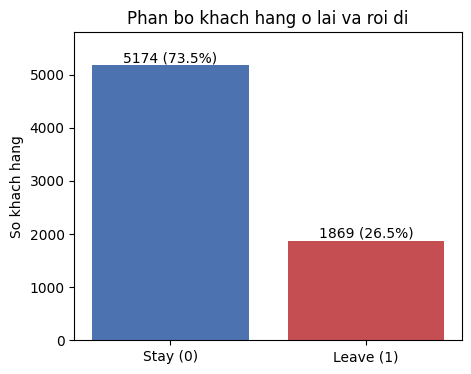

In [23]:
import matplotlib.pyplot as plt
# bieu do cot
counts = dfcopy["Churn"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5,4))
labels = ["Stay (0)", "Leave (1)"]
ax.bar(labels, counts.values, color=["#4C72B0", "#C44E52"])

for i, v in enumerate(counts.values):
    ax.text(i,v+60, f"{v} ({v/len(dfcopy):.1%})", ha="center")
ax.set_title("Phan bo khach hang o lai va roi di")
ax.set_ylabel("So khach hang")
ax.set_ylim(0, counts.max()*1.12)
plt.savefig("eda_churn_distribution.png", dpi=150, bbox_inches="tight")

plt.show()


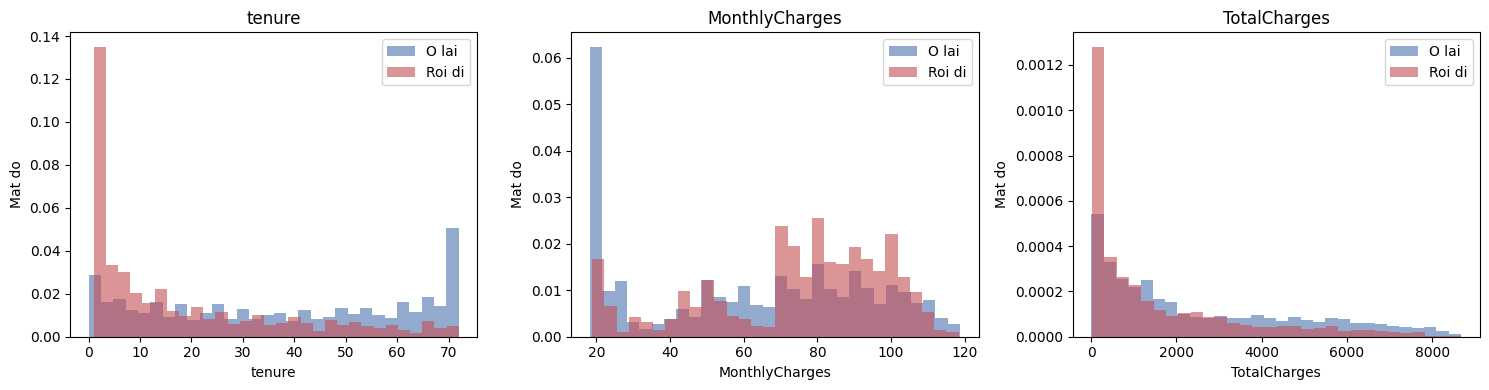

In [24]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    stay = dfcopy.loc[dfcopy["Churn"] == 0, col]
    left = dfcopy.loc[dfcopy["Churn"] == 1, col]
    ax.hist(stay, bins=30, alpha=0.6, density=True, label="O lai", color = "#4C72B0")
    ax.hist(left, bins=30, alpha=0.6, density=True, label="Roi di", color="#C44E52")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Mat do")
    ax.legend()

plt.tight_layout()
plt.savefig("eda_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()



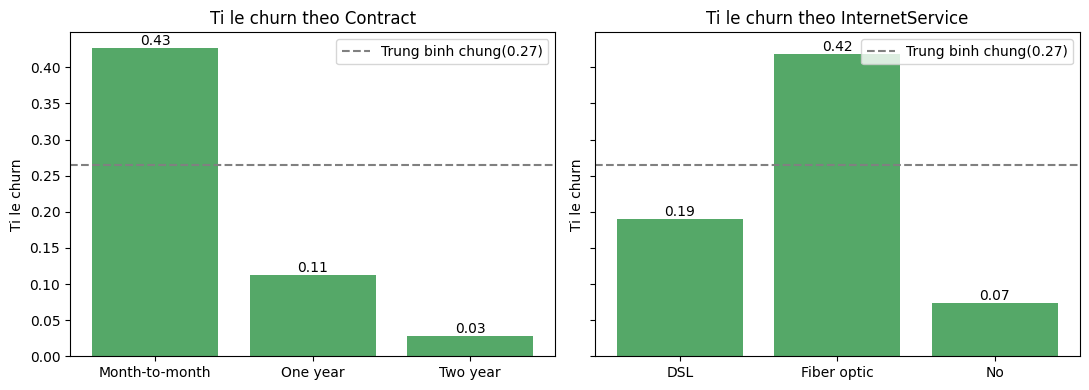

In [25]:
cat_cols = ["Contract", "InternetService"]
overall = dfcopy["Churn"].mean()
fig,axes = plt.subplots(1,2,figsize=(11,4), sharey=True)
for ax, col in zip(axes, cat_cols):
    rate = dfcopy.groupby(col)["Churn"].mean()
    bars = ax.bar(rate.index, rate.values, color="#55A868")
    ax.bar_label(bars, fmt="%.2f")
    ax.axhline(overall, color="gray", linestyle="--", label=f"Trung binh chung({overall:.2f})")
    ax.set_title(f"Ti le churn theo {col}")
    ax.set_ylabel("Ti le churn")
    ax.legend()
plt.tight_layout()
plt.savefig("eda_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


In [27]:

dfcopy[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(2)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00
